# E-Commerce Return Prediction — Machine Learning

## Objective

This notebook develops a machine-learning classification model to estimate
the probability that an e-commerce order will be returned.

The model is intended to act as an **early-warning system** that can help
an e-commerce business identify potentially high-risk orders and prioritize
appropriate interventions.

### Machine Learning Pipeline

**Clean Dataset → Problem Definition → Leakage Check → Feature Preparation
→ Train/Test Split → Baseline → Model Training → Cross-Validation
→ Evaluation → Model Selection**

## Business Problem

Product returns can create additional costs through:

- Reverse logistics
- Refund processing
- Inventory handling
- Customer support
- Operational overhead

The exploratory analysis identified differences in return rates across
product categories, locations, discount levels, and other transaction
characteristics.

The next step is to determine whether these characteristics can be combined
to estimate the likelihood of an individual order being returned.

### Business Question

> **Can historical order information available at the time of purchase be
> used to estimate the probability that an order will be returned?**

The objective is not to automatically reject or cancel high-risk orders.

Instead, the model is intended to provide an additional signal that could
support proactive customer communication, order verification, or other
return-prevention strategies.

## Machine Learning Problem Definition

Return prediction is formulated as a **binary classification problem**.

### Target Variable

`isreturned`

```text
0 → Order was not returned
1 → Order was returned

The intended prediction point is **when the customer places the order**.

Therefore, the model should only use information that would reasonably be
available at that point in time.

### Available at Order Placement

Examples include:

- Product category
- Quantity
- Price
- Payment method
- Customer location
- Customer segment
- Discount
- Order month

### Not Available at Order Placement

Examples include:

- Actual delivery duration
- Whether the order was eventually returned

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

## Load the Cleaned Dataset

The validated dataset produced by the data-cleaning stage is used as the
starting point for model development.

### Input

`data/cleaned/ecommerce_cleaned.csv`

The raw dataset is not used directly because data-quality issues were
already addressed during the cleaning and validation stage.

In [2]:
df = pd.read_csv("../data/cleaned/ecommerce_cleaned.csv")

df.head()

,orderid,orderdate,productcategory,quantity,priceperunit,paymentmethod,customerlocation,customersegment,discountapplied,deliverytimedays,isreturned,totalamount,order_month
0,Ord100000,2023-06-26,Electronics,4,3968.220,Credit Card,Bangalore,New,0.18,4.0,0,13015.76,6
1,Ord100001,2023-09-24,Books,3,1554.250,Net Banking,Chennai,New,0.20,5.0,1,3730.20,9
2,Ord100002,2023-12-07,Books,4,2752.710,Cash On Delivery,Delhi,Vip,0.05,5.0,1,10460.30,12
3,Ord100003,2023-10-09,Books,1,2765.735,Credit Card,Chennai,New,0.29,1.0,0,1963.67,10
4,Ord100004,2023-03-04,Books,2,2765.735,Net Banking,Chennai,Regular,0.16,7.0,0,4646.43,3


In [3]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate Order IDs:")
print(df["orderid"].duplicated().sum())

Dataset shape: (1000, 13)

Missing values:
orderid             0
orderdate           0
productcategory     0
quantity            0
priceperunit        0
paymentmethod       0
customerlocation    0
customersegment     0
discountapplied     0
deliverytimedays    0
isreturned          0
totalamount         0
order_month         0
dtype: int64

Duplicate Order IDs:
0


## Define Features and Target

The target variable is separated from the predictor variables.

### Target

```text
isreturned

In [5]:
target = "isreturned"

X = df.drop(columns=[target])
y = df[target]

In [6]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (1000, 12)
Target: (1000,)


## 8. Data Leakage Prevention

Data leakage occurs when information unavailable at prediction time is used
to train a model.

Because this project aims to predict return risk **at order placement**,
variables that become known only after fulfillment must not be used.

### Explicitly Excluded Variables

#### `orderid`

An identifier with no meaningful predictive interpretation.

#### `orderdate`

The raw date is replaced by the derived `order_month` feature.

#### `deliverytimedays`

Actual delivery duration is only known after fulfillment.

Using it would allow the model to learn from information that would not be
available when the prediction is required.

#### `totalamount`

This is a derived transactional value based on other available variables.
It is excluded to avoid unnecessary redundancy.

### Result

The final feature set represents information that can reasonably be known
when an order is placed.

In [7]:
columns_to_exclude = [
    "orderid",
    "orderdate",
    "deliverytimedays",
    "totalamount"
]

X = X.drop(columns=columns_to_exclude)

## Target Variable Distribution

The distribution of the target variable is examined before splitting the
dataset.

This is important because classification models can be affected when one
class is substantially more frequent than another.

The return and non-return classes will therefore be checked before model
training.

In [8]:
target_distribution = (
    y.value_counts()
     .rename(index={
         0: "Not Returned",
         1: "Returned"
     })
)

target_distribution

isreturned
Not Returned    646
Returned        354
Name: count, dtype: int64

In [9]:
target_percentage = (
    y.value_counts(normalize=True)
     .mul(100)
     .round(2)
     .rename(index={
         0: "Not Returned",
         1: "Returned"
     })
)

target_percentage

isreturned
Not Returned    64.6
Returned        35.4
Name: proportion, dtype: float64

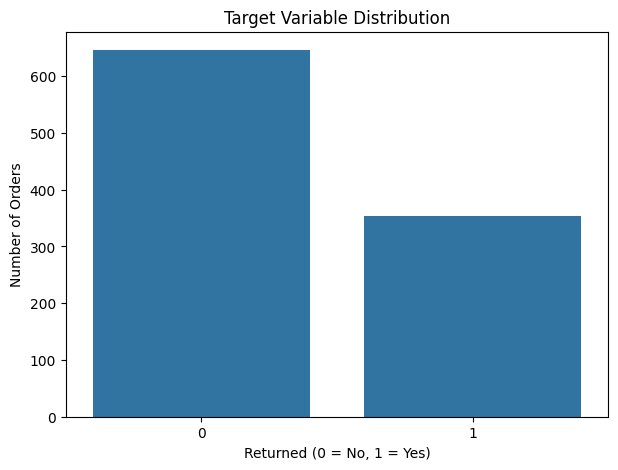

In [10]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x=y
)

plt.title("Target Variable Distribution")
plt.xlabel("Returned (0 = No, 1 = Yes)")
plt.ylabel("Number of Orders")

plt.show()

## Final Feature Set

The final predictive feature set is:

| Feature | Type | Reason for Inclusion |
|---|---|---|
| `productcategory` | Categorical | Product characteristics |
| `quantity` | Numerical | Order quantity |
| `priceperunit` | Numerical | Transaction value |
| `paymentmethod` | Categorical | Payment behavior |
| `customerlocation` | Categorical | Geographic information |
| `customersegment` | Categorical | Customer classification |
| `discountapplied` | Numerical | Promotional information |
| `order_month` | Numerical/Categorical | Temporal pattern |

These features will be transformed using a preprocessing pipeline before
being supplied to the machine-learning models.

In [11]:
numeric_features = [
    "quantity",
    "priceperunit",
    "discountapplied"
]

categorical_features = [
    "productcategory",
    "paymentmethod",
    "customerlocation",
    "customersegment",
    "order_month"
]

In [12]:
print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['quantity', 'priceperunit', 'discountapplied']

Categorical features:
['productcategory', 'paymentmethod', 'customerlocation', 'customersegment', 'order_month']


In [13]:
X[numeric_features].describe()

,quantity,priceperunit,discountapplied
count,1000.000000,1000.000000,1000.000000
mean,2.459000,2568.166410,0.147130
std,1.080503,1327.978754,0.086017
min,1.000000,106.600000,0.000000
25%,2.000000,1485.070000,0.070000
50%,2.000000,2657.570000,0.145000
75%,3.000000,3648.767500,0.220000
max,4.000000,4988.350000,0.300000


In [14]:
for col in categorical_features:
    print(f"\n{col}")
    print(X[col].value_counts())


productcategory
productcategory
Electronics       197
Books             172
Home & Kitchen    172
Beauty            162
Toys              153
Fashion           144
Name: count, dtype: int64

paymentmethod
paymentmethod
Net Banking         270
Cash On Delivery    250
Credit Card         241
Upi                 239
Name: count, dtype: int64

customerlocation
customerlocation
Chennai      174
Delhi        173
Bangalore    165
Mumbai       165
Pune         165
Hyderabad    158
Name: count, dtype: int64

customersegment
customersegment
New        355
Regular    353
Vip        292
Name: count, dtype: int64

order_month
order_month
1     97
8     94
11    89
10    88
12    86
4     86
6     84
2     80
9     77
3     77
5     73
7     69
Name: count, dtype: int64


## Train-Test Split

The dataset is divided into training and test sets.

### Training Set

Used to:

- Learn model parameters
- Perform preprocessing
- Perform cross-validation
- Select the final model

### Test Set

Used only for final evaluation after model selection.

A **stratified split** is used so that the proportion of returned and
non-returned orders remains approximately consistent across the training
and test sets.

This is particularly important for classification problems where the target
classes may not be perfectly balanced.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [16]:
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training shape: (800, 8)
Testing shape: (200, 8)

Training target distribution:
isreturned
0    0.646
1    0.354
Name: proportion, dtype: float64

Testing target distribution:
isreturned
0    0.645
1    0.355
Name: proportion, dtype: float64


## Build the Preprocessing Pipeline

The preprocessing pipeline separates numerical and categorical
transformations.

This allows the same preprocessing logic to be applied consistently during:

- Training
- Cross-validation
- Testing
- Future predictions

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [18]:
X_train_transformed = preprocessor.fit_transform(X_train)

X_test_transformed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Transformed training shape:", X_train_transformed.shape)

print("Original testing shape:", X_test.shape)
print("Transformed testing shape:", X_test_transformed.shape)

Original training shape: (800, 8)
Transformed training shape: (800, 34)
Original testing shape: (200, 8)
Transformed testing shape: (200, 34)


In [19]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nFirst 30 features:")
print(feature_names[:30])

Number of processed features: 34

First 30 features:
['num__quantity' 'num__priceperunit' 'num__discountapplied'
 'cat__productcategory_Beauty' 'cat__productcategory_Books'
 'cat__productcategory_Electronics' 'cat__productcategory_Fashion'
 'cat__productcategory_Home & Kitchen' 'cat__productcategory_Toys'
 'cat__paymentmethod_Cash On Delivery' 'cat__paymentmethod_Credit Card'
 'cat__paymentmethod_Net Banking' 'cat__paymentmethod_Upi'
 'cat__customerlocation_Bangalore' 'cat__customerlocation_Chennai'
 'cat__customerlocation_Delhi' 'cat__customerlocation_Hyderabad'
 'cat__customerlocation_Mumbai' 'cat__customerlocation_Pune'
 'cat__customersegment_New' 'cat__customersegment_Regular'
 'cat__customersegment_Vip' 'cat__order_month_1' 'cat__order_month_2'
 'cat__order_month_3' 'cat__order_month_4' 'cat__order_month_5'
 'cat__order_month_6' 'cat__order_month_7' 'cat__order_month_8']


In [20]:
print(
    "Missing values in X_train:",
    X_train.isnull().sum().sum()
)

print(
    "Missing values in X_test:",
    X_test.isnull().sum().sum()
)

print(
    "Missing values in y_train:",
    y_train.isnull().sum()
)

print(
    "Missing values in y_test:",
    y_test.isnull().sum()
)

Missing values in X_train: 0
Missing values in X_test: 0
Missing values in y_train: 0
Missing values in y_test: 0


In [21]:
def create_pipeline(model):
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

## Establish a Baseline

Before comparing machine-learning algorithms, a baseline model is used to
establish a simple reference point.

A `DummyClassifier` can predict the majority class without learning
relationships between features.

The purpose of the baseline is to answer:

> **Does the machine-learning model provide useful predictive information
> beyond simply predicting the most common class?**

A useful model should demonstrate performance beyond this baseline,
particularly on metrics such as recall, F1-score, and ROC-AUC.

In [23]:
baseline_accuracy = y_test.value_counts(normalize=True).max()

print(
    f"Majority-class baseline accuracy: "
    f"{baseline_accuracy:.2%}"
)

Majority-class baseline accuracy: 64.50%


In [24]:
print("=" * 50)
print("ML PREPROCESSING VALIDATION")
print("=" * 50)

print(f"Original dataset: {df.shape}")
print(f"Training records: {X_train.shape[0]}")
print(f"Testing records: {X_test.shape[0]}")

print("\nFeatures used:")
for feature in X.columns:
    print(f"  - {feature}")

print("\nExcluded features:")
for feature in columns_to_exclude:
    print(f"  - {feature}")

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print(f"\nProcessed feature count: {len(feature_names)}")

print(f"\nBaseline accuracy: {baseline_accuracy:.2%}")

print("\nPreprocessing pipeline ready.")

ML PREPROCESSING VALIDATION
Original dataset: (1000, 13)
Training records: 800
Testing records: 200

Features used:
  - productcategory
  - quantity
  - priceperunit
  - paymentmethod
  - customerlocation
  - customersegment
  - discountapplied
  - order_month

Excluded features:
  - orderid
  - orderdate
  - deliverytimedays
  - totalamount

Numerical features:
['quantity', 'priceperunit', 'discountapplied']

Categorical features:
['productcategory', 'paymentmethod', 'customerlocation', 'customersegment', 'order_month']

Processed feature count: 34

Baseline accuracy: 64.50%

Preprocessing pipeline ready.


## Evaluation Metrics

Accuracy alone is not sufficient for evaluating this problem.

A model could achieve reasonable accuracy by favoring the majority class
while performing poorly at identifying actual returns.

Therefore, the following metrics are considered:

### Accuracy

Overall proportion of correct predictions.

### Precision

Of the orders predicted as returns, how many were actually returned?

### Recall

Of the orders that were actually returned, how many did the model identify?

### F1 Score

Harmonic mean of precision and recall.

### ROC-AUC

Measures the model's ability to distinguish returned and non-returned
orders across different classification thresholds.

### Primary Consideration

Because the business may want to identify potentially return-prone orders,
**recall and ROC-AUC are particularly important**, while precision and F1
help assess whether the resulting predictions remain practical.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.model_selection import cross_validate, StratifiedKFold

## Models to Compare

Three classification algorithms are evaluated:

### 1. Logistic Regression

Provides a simple and interpretable linear baseline.

### 2. Decision Tree

Can capture nonlinear relationships and produces relatively interpretable
decision rules.

### 3. Random Forest

Combines multiple decision trees and can capture more complex nonlinear
relationships while generally providing robust performance on tabular data.

The models will be compared using the same preprocessing strategy and
evaluation methodology.

In [26]:
logistic_model = create_pipeline(
    LogisticRegression(
        max_iter=1000,
        random_state=42
    )
)

decision_tree_model = create_pipeline(
    DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=10,
        random_state=42
    )
)

random_forest_model = create_pipeline(
    RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
)

In [27]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

In [28]:
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.


In [29]:
predictions = {}
probabilities = {}

for name, model in models.items():
    
    predictions[name] = model.predict(X_test)
    
    probabilities[name] = model.predict_proba(X_test)[:, 1]

In [30]:
results = []

for name in models.keys():
    
    y_pred = predictions[name]
    y_prob = probabilities[name]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.61,0.181818,0.028169,0.048780,0.555082
1,Decision Tree,0.60,0.384615,0.211268,0.272727,0.481057
2,Random Forest,0.64,0.000000,0.000000,0.000000,0.541107


In [31]:
results_display = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

results_display[metric_columns] = (
    results_display[metric_columns] * 100
).round(2)

results_display

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,61.0,18.18,2.82,4.88,55.51
1,Decision Tree,60.0,38.46,21.13,27.27,48.11
2,Random Forest,64.0,0.00,0.00,0.00,54.11


In [32]:
print(
    f"Majority-class baseline accuracy: "
    f"{baseline_accuracy:.2%}"
)

print(
    f"Best model accuracy: "
    f"{results_df['Accuracy'].max():.2%}"
)

Majority-class baseline accuracy: 64.50%
Best model accuracy: 64.00%


In [33]:
best_model_by_auc = results_df.loc[
    results_df["ROC-AUC"].idxmax()
]

print(
    "Best model based on ROC-AUC:",
    best_model_by_auc["Model"]
)

Best model based on ROC-AUC: Logistic Regression


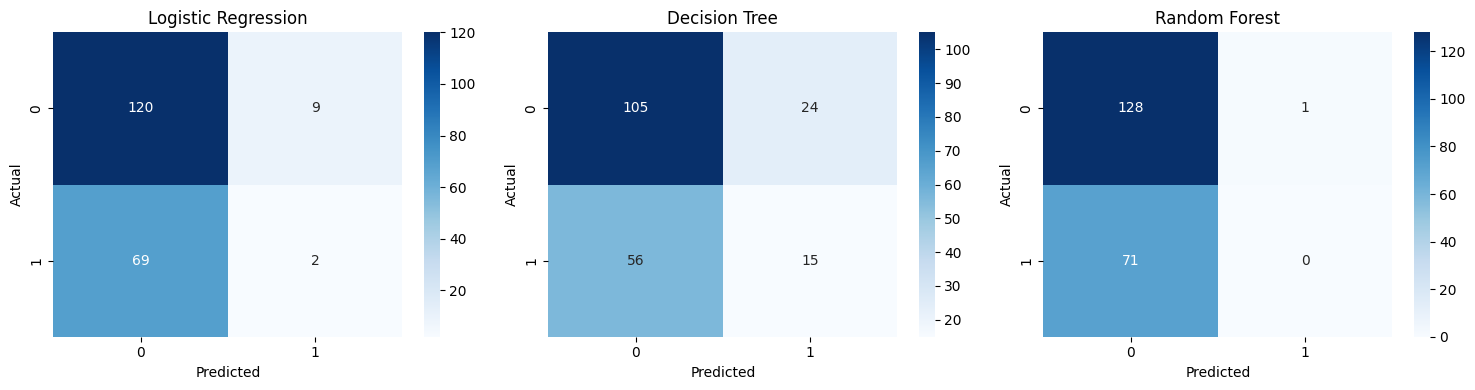

In [34]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

for ax, (name, y_pred) in zip(
    axes,
    predictions.items()
):
    
    cm = confusion_matrix(
        y_test,
        y_pred
    )
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )
    
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

### Classification Report

The classification report provides class-level precision, recall, and
F1-score.

Particular attention is paid to the `Returned` class because identifying
actual returns is central to the business objective.

In [35]:
for name in models.keys():
    
    print("=" * 60)
    print(name)
    print("=" * 60)
    
    print(
        classification_report(
            y_test,
            predictions[name],
            target_names=[
                "Not Returned",
                "Returned"
            ]
        )
    )

Logistic Regression
              precision    recall  f1-score   support

Not Returned       0.63      0.93      0.75       129
    Returned       0.18      0.03      0.05        71

    accuracy                           0.61       200
   macro avg       0.41      0.48      0.40       200
weighted avg       0.47      0.61      0.50       200

Decision Tree
              precision    recall  f1-score   support

Not Returned       0.65      0.81      0.72       129
    Returned       0.38      0.21      0.27        71

    accuracy                           0.60       200
   macro avg       0.52      0.51      0.50       200
weighted avg       0.56      0.60      0.56       200

Random Forest
              precision    recall  f1-score   support

Not Returned       0.64      0.99      0.78       129
    Returned       0.00      0.00      0.00        71

    accuracy                           0.64       200
   macro avg       0.32      0.50      0.39       200
weighted avg       0.41   

## ROC-AUC Analysis

The ROC curve illustrates how the model's true-positive rate changes
relative to its false-positive rate across different classification
thresholds.

ROC-AUC summarizes the model's ability to distinguish between returned and
non-returned orders.

A higher ROC-AUC generally indicates stronger discrimination.

<Figure size 800x600 with 0 Axes>

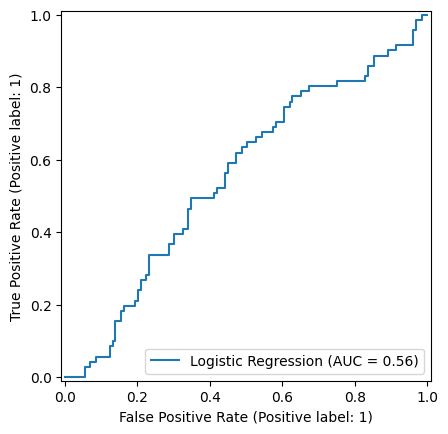

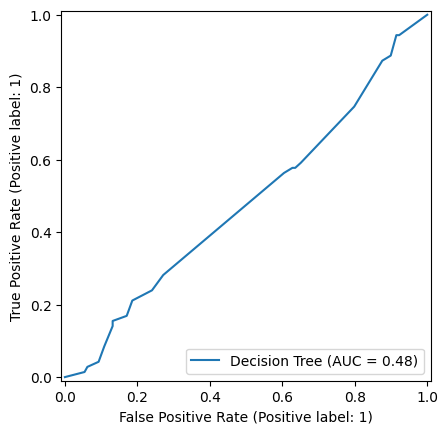

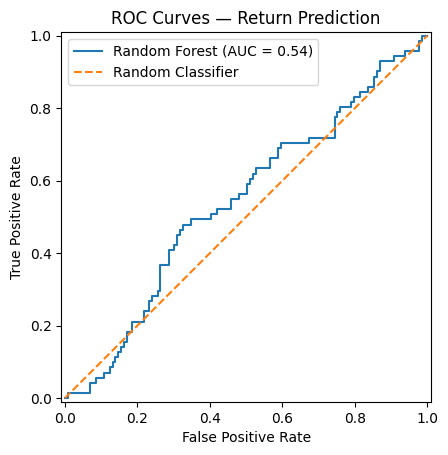

In [36]:
plt.figure(figsize=(8, 6))

for name in models.keys():
    
    RocCurveDisplay.from_predictions(
        y_test,
        probabilities[name],
        name=name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curves — Return Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()

## Cross-Validation

A single train/test split can produce model performance that depends on the
specific observations assigned to each set.

To obtain a more reliable estimate during model selection, **5-fold
Stratified Cross-Validation** is used on the training data.

### Process

```text
Training Data
      ↓
 ┌────┬────┬────┬────┬────┐
 │ F1 │ F2 │ F3 │ F4 │ F5 │
 └────┴────┴────┴────┴────┘
      ↓
Train on 4 folds
Validate on 1 fold
      ↓
Repeat 5 times
      ↓
Calculate Mean Performance

In [37]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [38]:
cv_results = []

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

for name, model in models.items():
    
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    cv_results.append({
        "Model": name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Precision Mean": scores["test_precision"].mean(),
        "Recall Mean": scores["test_recall"].mean(),
        "F1 Mean": scores["test_f1"].mean(),
        "ROC-AUC Mean": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean
0,Logistic Regression,0.625,0.020248,0.366734,0.039517,0.066916,0.484349
1,Decision Tree,0.614,0.030397,0.379109,0.098753,0.150982,0.488515
2,Random Forest,0.644,0.003742,0.100000,0.005714,0.010811,0.485013


In [39]:
cv_display = cv_results_df.copy()

cv_metric_columns = [
    "Accuracy Mean",
    "Precision Mean",
    "Recall Mean",
    "F1 Mean",
    "ROC-AUC Mean"
]

cv_display[cv_metric_columns] = (
    cv_display[cv_metric_columns] * 100
).round(2)

cv_display["Accuracy Std"] = (
    cv_display["Accuracy Std"] * 100
).round(2)

cv_display

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean
0,Logistic Regression,62.5,2.02,36.67,3.95,6.69,48.43
1,Decision Tree,61.4,3.04,37.91,9.88,15.10,48.85
2,Random Forest,64.4,0.37,10.00,0.57,1.08,48.50


### Model Comparison

The cross-validation results provide a more reliable basis for model
selection than a single train/test score.

The final model will be selected based on the overall balance of:

- ROC-AUC
- Recall
- F1 Score
- Precision
- Accuracy
- Cross-validation stability

The selected model should also be sufficiently interpretable for the
business use case.

In [40]:
best_model_name = cv_results_df.loc[
    cv_results_df["ROC-AUC Mean"].idxmax(),
    "Model"
]

print("Best model based on mean CV ROC-AUC:")
print(best_model_name)

Best model based on mean CV ROC-AUC:
Decision Tree


## Final Model Selection

Based on the cross-validation results, **Decision Tree** is selected as the
final model.

### Selection Rationale

The model was selected because it provided the strongest overall balance
between predictive discrimination and the business objective of identifying
potential return orders.

The selection was based on cross-validation performance rather than
choosing a model solely because it achieved the highest training accuracy.

In [41]:
best_model = models[best_model_name]

print(best_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['quantity', 'priceperunit',
                                                   'discountapplied']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['productcategory',
                                                   'paymentmethod',
                                                   'customerlocation',
                                                   'customersegment',
                                                   'order_month'])])),
                ('model',
                 DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                        random_state=42))])

In [42]:
import joblib

joblib.dump(
    best_model,
    "../outputs/return_prediction_model.pkl"
)

['../outputs/return_prediction_model.pkl']

In [43]:
print("=" * 60)
print("RETURN PREDICTION — FINAL MODEL SUMMARY")
print("=" * 60)

print(f"\nSelected Model: {best_model_name}")

best_row = cv_results_df[
    cv_results_df["Model"] == best_model_name
].iloc[0]

print(
    f"Mean CV Accuracy: "
    f"{best_row['Accuracy Mean']:.2%}"
)

print(
    f"Mean CV Precision: "
    f"{best_row['Precision Mean']:.2%}"
)

print(
    f"Mean CV Recall: "
    f"{best_row['Recall Mean']:.2%}"
)

print(
    f"Mean CV F1 Score: "
    f"{best_row['F1 Mean']:.2%}"
)

print(
    f"Mean CV ROC-AUC: "
    f"{best_row['ROC-AUC Mean']:.2%}"
)

RETURN PREDICTION — FINAL MODEL SUMMARY

Selected Model: Decision Tree
Mean CV Accuracy: 61.40%
Mean CV Precision: 37.91%
Mean CV Recall: 9.88%
Mean CV F1 Score: 15.10%
Mean CV ROC-AUC: 48.85%


# Summary

This notebook developed an end-to-end machine-learning pipeline for
e-commerce return prediction.

### Completed

- Defined the return-prediction problem
- Established the prediction point
- Prevented data leakage
- Selected appropriate predictive features
- Performed stratified train/test splitting
- Built preprocessing pipelines
- Established a baseline
- Compared Logistic Regression, Decision Tree, and Random Forest
- Applied five-fold stratified cross-validation
- Evaluated the final model on unseen test data
- Analyzed the confusion matrix and ROC-AUC

### Final Project Flow

```text
Clean Dataset
      ↓
Define Prediction Point
      ↓
Leakage Prevention
      ↓
Feature Selection
      ↓
Train/Test Split
      ↓
Preprocessing Pipeline
      ↓
Baseline
      ↓
Model Comparison
      ↓
Cross-Validation
      ↓
Final Model
      ↓
Test Evaluation
      ↓
Power BI